<a href="https://colab.research.google.com/github/christiewong219/Team-5-CS105-Final-Project/blob/ltphase3/Team5_CS105_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [163]:
#pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

In [164]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.neighbors import KNeighborsClassifier
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import Normalizer

RANDOM_STATE = 42

In [165]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Not running in Google Colab, skipping drive mount.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **CS105 Final Project**

## Project Description

[description goes here]

## **Phase 2: Supervised Learning**
The purpose of this project is to use the corpus created in Phase 1 for supervised learning to analyze and measure the document.
* We will read and tokenize the documents.
* Vectorize the corpus using Bag-of-Words (BoW) or one-hot encoding (OHE).
* Apply TF-IDF to the BoW representation, and compare the results with the original BoW representation for
at least some tasks.

## Preparing Data

Read the corpus from phase 1 and drop the incomplete row.

In [166]:
# Loading data
df = pd.read_csv("AllCorpus - Corpus.csv")
print(df.shape)

# Drop empty rows
df = df.dropna()
df.head()
print(df.shape)


(810, 5)
(693, 5)


## **Converting the documents**
### Tokenize the text
* We clean the text column by making each word to lowercase and remove all the symbol.
* Then spilt each word and tokenize them.


In [167]:
# standardize the text and remove signs
def clean(text):
  text = text.lower()
  text = re.sub(r'[^a-z0-9\s]', '', text)
  tokens = text.split()
  return str(tokens)
  #return

df['text'] = df['text'].apply(clean)

# standardize the labels for sentiment
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.replace('.', '', regex=False).str.lower()
typo_map = {
  'netural': 'neutral',
  'nuetral': 'neutral',
  'positve': 'positive',
  'negative': 'negative'
}
df['sentiment'] = df['sentiment'].replace(typo_map)
df.head()

,doc_id,text,category_1,category_2,sentiment
0,1,"['trumps', 'presidency', 'has', 'been', 'tatte...",1,none,negative
1,2,"['my', 'machine', 'learning', 'course', 'has',...",2,none,positive
2,3,"['the', 'plot', 'of', 'the', 'final', 'season'...",3,none,negative
3,4,"['i', 'enjoy', 'getting', 'learning', 'about',...",4,none,positive
4,5,"['its', 'concerning', 'our', 'government', 'is...",1,2,negative


### Vectorization

* remove the common english word use for filler without any meaning
* Generate the matrixes with three different ways for training models.
* convert to dataframe with each words apears/frequency/weight for each corpus.

In [168]:
# remove common filler words
bow_vectorizer = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer = TfidfVectorizer(stop_words="english")

# count the amount of time each word appears
X_bow = bow_vectorizer.fit_transform(df["text"])

# One-hot Encoded, track if the word exist
X_binary = binary_vectorizer.fit_transform(df["text"])

# score a word to the dataset - weight
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame(np.round(X_tfidf.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())

print(bow_df.head())
print(binary_df.head())
print(tfidf_df.head())

#print(bow_df.shape)
#print(binary_df.shape)
#print(tfidf_df.shape)



   10  10000  111  12  1990s  2026  2028  30  5150  5k  ...  year  years  \
0   0      0    0   0      0     0     0   0     0   0  ...     0      0   
1   0      0    0   0      0     0     0   0     0   0  ...     0      0   
2   0      0    0   0      0     0     0   0     0   0  ...     0      0   
3   0      0    0   0      0     0     0   0     0   0  ...     0      0   
4   0      0    0   0      0     0     0   0     0   0  ...     0      0   

   yesterdays  yoga  young  younger  youtube  zones  zongs  zoomies  
0           0     0      0        0        0      0      0        0  
1           0     0      0        0        0      0      0        0  
2           0     0      0        0        0      0      0        0  
3           0     0      0        0        0      0      0        0  
4           0     0      0        0        0      0      0        0  

[5 rows x 3452 columns]
   10  10000  111  12  1990s  2026  2028  30  5150  5k  ...  year  years  \
0   0      0    0   0 

## **Supervised Learning**

* Clearly describe each task. For each task: implement the methods, run experiments, and analyze the results.

* For distance-based methods, use cosine similarity where appropriate. For at least two techniques, compare cosine
similarity with binary feature presence representations. Include visualizations where appropriate

### **Logistic Regression**
We are comparing category classification between TF-IDF and BoW representations to see which one performs better or worse.

Accuracy from BoW: 0.74713
              precision    recall  f1-score   support

           1       0.88      0.79      0.83        47
           2       0.69      0.92      0.79        39
           3       0.71      0.67      0.69        33
           4       0.78      0.74      0.76        34
           5       0.59      0.48      0.53        21

    accuracy                           0.75       174
   macro avg       0.73      0.72      0.72       174
weighted avg       0.75      0.75      0.74       174

Accuracy from TF-IDF: 0.75287
              precision    recall  f1-score   support

           1       0.67      0.87      0.76        47
           2       0.73      0.97      0.84        39
           3       0.82      0.55      0.65        33
           4       0.84      0.79      0.82        34
           5       1.00      0.33      0.50        21

    accuracy                           0.75       174
   macro avg       0.81      0.70      0.71       174
weighted avg       0

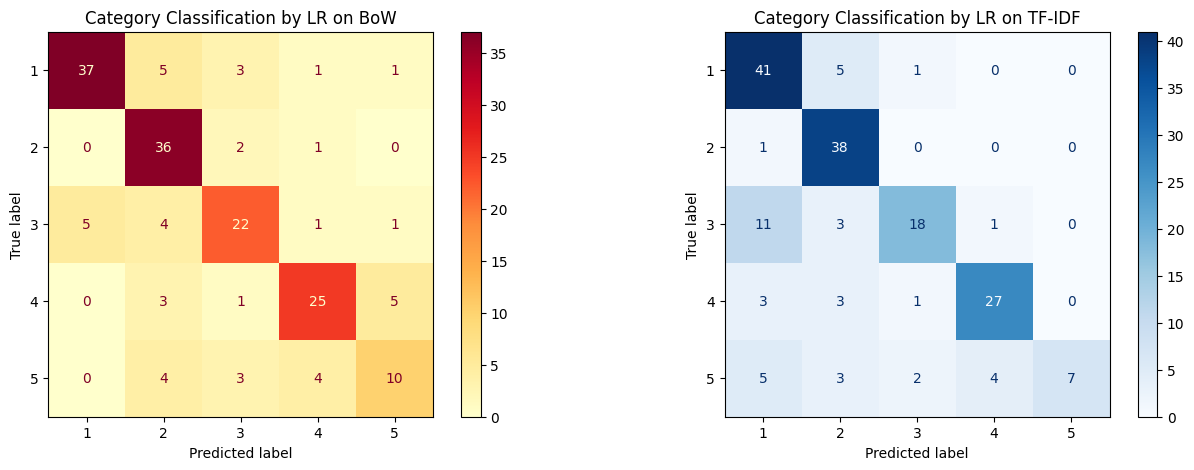

In [169]:
log_model = LogisticRegression(max_iter = 200, random_state = RANDOM_STATE)

# LR on BoW
X_trainbow, X_testbow, y_trainbow, y_testbow = train_test_split(
    X_bow,
    df["category_1"],
    test_size = 0.25,
    random_state = RANDOM_STATE,
    stratify = df["category_1"]
)

log_model.fit(X_trainbow, y_trainbow)
y_pred_bow = log_model.predict(X_testbow)
accuracy_bow = accuracy_score(y_testbow, y_pred_bow)

# LR on Tf-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    df["category_1"],
    test_size = 0.25,
    random_state = RANDOM_STATE,
    stratify = df["category_1"]
)

log_model.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = log_model.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test_tfidf, y_pred_tfidf)

# Accuracy
print(f"Accuracy from BoW: {accuracy_bow:.5f}")
print(classification_report(y_testbow, y_pred_bow, zero_division = 0))
print(f"Accuracy from TF-IDF: {accuracy_tfidf:.5f}")
print(classification_report(y_test_tfidf, y_pred_tfidf, zero_division = 0))

# plotting confusion matrices
fig, axes = plt.subplots(1, 2, figsize = (16, 5))
cm_bow = confusion_matrix(y_testbow, y_pred_bow)
cm_tfidf = confusion_matrix(y_test_tfidf, y_pred_tfidf)

# fixing labels
cat_labels = sorted(df["category_1"].unique())

ConfusionMatrixDisplay(cm_bow, display_labels = cat_labels).plot(ax = axes[0], cmap = "YlOrRd")
axes[0].set_title("Category Classification by LR on BoW")
ConfusionMatrixDisplay(cm_tfidf, display_labels = cat_labels).plot(ax = axes[1], cmap = "Blues")
axes[1].set_title("Category Classification by LR on TF-IDF")

plt.show()

**Analyze**: Both BoW and TF-IDF yielded similar accuracy scores of about 75%. Both graphs seemed to have the highest recall rates with respect to Category 2 on computer and data science but had the lowest recall rates with Category 5. For the precision rates, Category 5 had the highest precision rate of 100% for the TF-IDF graph, and the BoW graph had the highest precision rate of 88% for Category 1. It seems that TF-IDF is better at predicting Categories 1 and 2 than BoW. For Category 3, TF-IDF seems to have a good tendency of predicting Category 3 instances as belonging to Category 1.

### **K-Nearest Neighbors (kNN)**

Accuracy:  0.6264367816091954
              precision    recall  f1-score   support

           1       0.60      0.79      0.68        47
           2       0.54      0.67      0.60        39
           3       0.68      0.52      0.59        33
           4       0.71      0.50      0.59        34
           5       0.80      0.57      0.67        21

    accuracy                           0.63       174
   macro avg       0.67      0.61      0.62       174
weighted avg       0.65      0.63      0.62       174



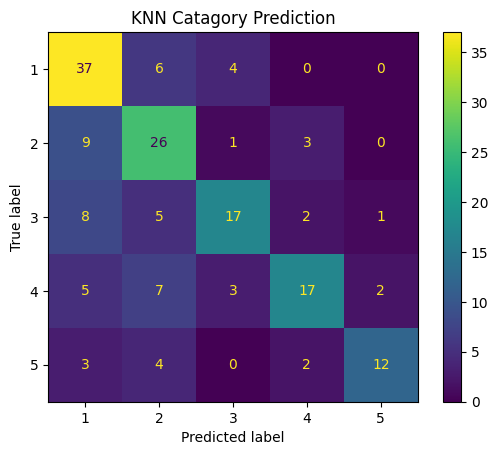

In [170]:
# Used this source for making kNN algorithm: https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/
y = df["category_1"]

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

knn = KNeighborsClassifier(n_neighbors=3, metric="cosine")
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("KNN Catagory Prediction")
plt.show()

**Analyze**:

### **Multinomial Naive Bayes**
We compare the Bag-of-words representation with the TF-IDF representation

(Satisfies - Apply TF-IDF to the BoW representation, and compare the results with the original BoW representation for
at least some tasks. )
(Satisfies - supervised model 1)


BoW Accuracy: 0.7758620689655172
              precision    recall  f1-score   support

           1       0.92      0.77      0.84        47
           2       0.73      0.95      0.82        39
           3       0.77      0.61      0.68        33
           4       0.88      0.85      0.87        34
           5       0.52      0.62      0.57        21

    accuracy                           0.78       174
   macro avg       0.76      0.76      0.75       174
weighted avg       0.79      0.78      0.78       174

TF-IDF Accuracy: 0.7758620689655172
              precision    recall  f1-score   support

           1       0.74      0.85      0.79        47
           2       0.70      0.97      0.82        39
           3       0.82      0.55      0.65        33
           4       0.89      0.91      0.90        34
           5       0.89      0.38      0.53        21

    accuracy                           0.78       174
   macro avg       0.81      0.73      0.74       174
weighted

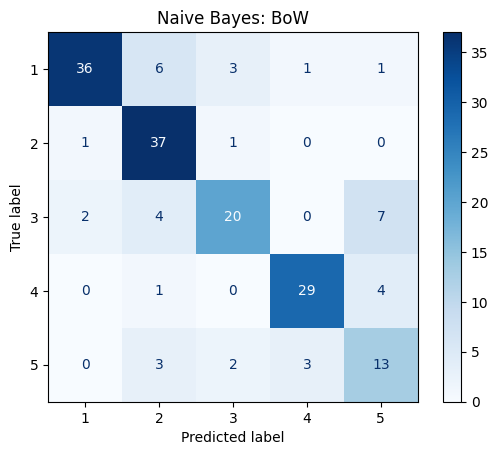

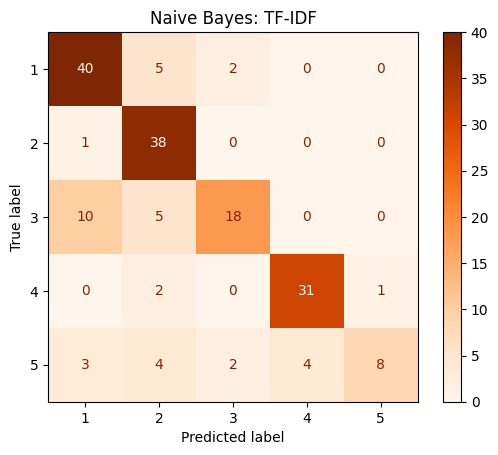

In [171]:
# this is one shared split
indices = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    indices,
    df["category_1"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["category_1"]
)

X_train_bow, X_test_bow = X_bow[idx_train], X_bow[idx_test]
X_train_tfidf, X_test_tfidf = X_tfidf[idx_train], X_tfidf[idx_test]

# alpha of 0.5 works for 810 documents that averate ~22 words
# eval BoW
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_bow, y_train)
y_pred_bow = nb.predict(X_test_bow)
acc_score_bow = accuracy_score(y_test, y_pred_bow)

print("BoW Accuracy:", acc_score_bow)
print(classification_report(y_test, y_pred_bow, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bow, cmap='Blues')
plt.title("Naive Bayes: BoW")

# eval td-idf
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb.predict(X_test_tfidf)
acc_score_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("TF-IDF Accuracy:", acc_score_tfidf)
print(classification_report(y_test, y_pred_tfidf, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tfidf, cmap='Oranges')
plt.title("Naive Bayes: TF-IDF")

if acc_score_bow > acc_score_tfidf:
    print("BoW has better accuracy than TF-IDF.")
elif acc_score_tfidf > acc_score_bow:
    print("TF-IDF has better accuracy than BoW.")
else:
    print("BoW and TF-IDF have equal accuracy.")

plt.show()

**Analyze**: Both BoW and IF-IDF have the same overall accuracy of 77.6%. The confusion matrices are different however. First looking at cetegory 5, the models act very differently. BoW has 62% recall on actual cat 5 documents but has a 52% precision rate, which is much different than TF-IDF. IF-IDF was more cautious rather than general with cat 5, as it had a 38% recall, missing many cat 5 documents, but held a 89% rate, so it was accurate when it felt a document was part of cat 5.

Cat 1 for both models resembles the opposite behavior or cat 5.

### **kNN (Binary feature comparison)**
This checks how binary feature presence affects a distance based model.

(Satisfies - For distance-based methods, use cosine similarity.)
(Satisfies - For at least two techniques...)

Binary kNN Accuracy:  0.6781609195402298
              precision    recall  f1-score   support

           1       0.70      0.83      0.76        47
           2       0.60      0.72      0.65        39
           3       0.72      0.55      0.62        33
           4       0.81      0.62      0.70        34
           5       0.60      0.57      0.59        21

    accuracy                           0.68       174
   macro avg       0.68      0.66      0.66       174
weighted avg       0.69      0.68      0.68       174

Accuracy: 0.764367816091954
              precision    recall  f1-score   support

           1       0.86      0.79      0.82        47
           2       0.71      0.92      0.80        39
           3       0.77      0.70      0.73        33
           4       0.79      0.76      0.78        34
           5       0.65      0.52      0.58        21

    accuracy                           0.76       174
   macro avg       0.75      0.74      0.74       174
weighted

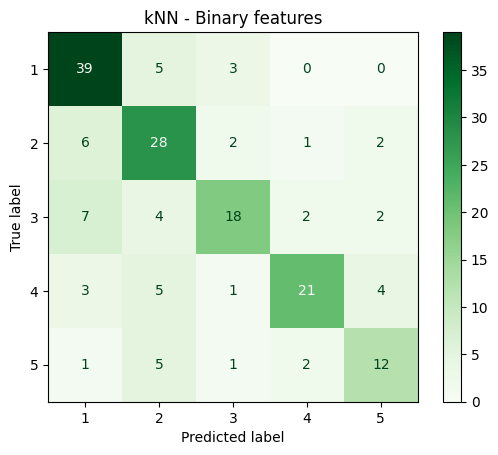

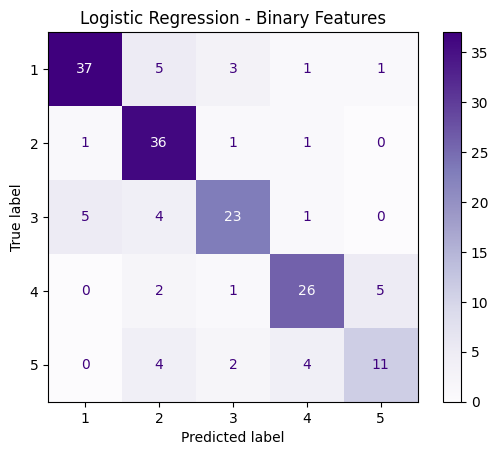

In [172]:
X_train_bin, X_test_bin = X_binary[idx_train], X_binary[idx_test]

# cosine sim for curse of dimensionality
knn_bin = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_bin.fit(X_train_bin, y_train)
y_pred_knn_bin = knn_bin.predict(X_test_bin)
acc_score_knn_bin = accuracy_score(y_test, y_pred_knn_bin)

print("Binary kNN Accuracy: ", acc_score_knn_bin)
print(classification_report(y_test, y_pred_knn_bin, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_bin, cmap='Greens')
plt.title("kNN - Binary features")

log_bin = LogisticRegression(random_state=RANDOM_STATE, max_iter=200)
log_bin.fit(X_train_bin, y_train)
y_pred_log_bin = log_bin.predict(X_test_bin)
acc_score_log_bin = accuracy_score(y_test, y_pred_log_bin)

print("Accuracy:", acc_score_log_bin)
print(classification_report(y_test, y_pred_log_bin, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_bin, cmap='Purples')
plt.title("Logistic Regression - Binary Features")

plt.show()

**Analyze**: Remember, the binary matrix ignores word frequency in its entirety. That is why the accuracy drops to 67.2% from somethign like 77.6% in the Naive Bayes models. Looking at category 3, we see that the kNN models has a recall of 52%. It thought that 8 of the docs that are cat 3 are actually cat 1.

Using an example to explain this: if a news document says 'software' once, and a computer science document says 'software' once also, the matrix ses these docs as equally related to the word 'computer'. The categories become much closer together in the model, which blurs the line between them.

Logistic regression has an accuracy of 76.4%, which is better than kNNs accuracy of 67.2%. Logistic regression is basically at bar or better than kNN here when looking at each value in the classification report.

### **Sentiment prediction with random forest**

Each sentence has a sentiment - either positive, negative, or neutral

(Satisfies - supervised model 2)



0 rows had sentiment typos.
Random Forest Sentiment Accuracy:  0.6436781609195402
              precision    recall  f1-score   support

    negative       0.94      0.61      0.74        56
     neutral       0.49      0.88      0.62        56
    positive       0.78      0.47      0.59        62

    accuracy                           0.64       174
   macro avg       0.74      0.65      0.65       174
weighted avg       0.74      0.64      0.65       174



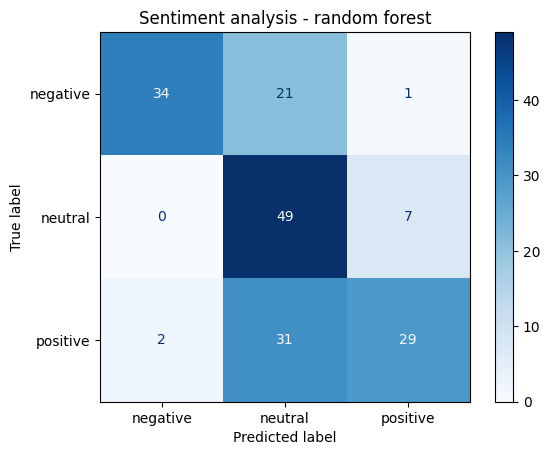

In [173]:
from sklearn.ensemble import RandomForestClassifier

# there are some typos from some silly people - purge them
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
mask = df['sentiment'].isin(['positive', 'negative', 'neutral'])
df_rf = df[mask]
X_tfidf_rf = X_tfidf[mask.values]

print(f"{len(df) - len(df_rf)} rows had sentiment typos.")

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_tfidf_rf,
    df_rf["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df_rf["sentiment"]
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)
acc_score_rf = accuracy_score(y_test_rf, y_pred_rf)

print("Random Forest Sentiment Accuracy: ", acc_score_rf)
print(classification_report(y_test_rf, y_pred_rf, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_rf, y_pred_rf, cmap='Blues')
plt.title("Sentiment analysis - random forest")
plt.show()

**Analyze**: Random forest had an overall accuracy of 68%. Sentiment is hard to predict because it is human emotion rather than a topic. The chart shows a huge neutral bias, which is responsible for the 93% neutral recall (rarely misses any document which are actually neutral). However, when a model did guess that a documen was negative or positive sentiment, it was right 97% and 84% of time time respectively, which is good.

This model is very cautious.

### **Sentiment prediction with KNN**

This task use a KNN to predict the sentimental.
1. Find optimal K using an elbow method
2. Using the K and use KNN on Binary feature and TF-IDF feature. Compare the confusing matric to see the different.

Optimal K for Binary kNN: 3 with test accuracy 0.5747
Optimal K for TF-IDF kNN: 19 with test accuracy 0.5862


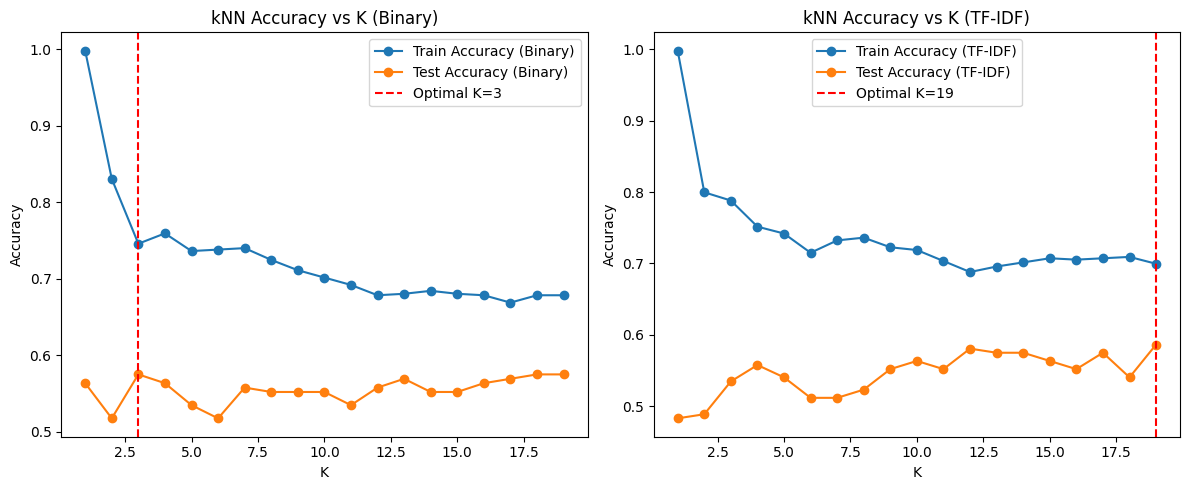

In [174]:
df_clean = df[mask].reset_index(drop=True)
y_sentiment = df_clean["sentiment"]
# split the data into train and test sets 75/25 split X_binary,
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary[mask.values], y_sentiment, test_size=0.25, random_state=RANDOM_STATE, stratify=y_sentiment
)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf[mask.values], y_sentiment, test_size=0.25, random_state=RANDOM_STATE, stratify=y_sentiment
)

#Find the optimal K value for kNN using the elbow method
k_values = range(1, 20)
train_accuracies_binary = []
test_accuracies_binary = []
train_accuracies_tfidf = []
test_accuracies_tfidf = []

for k in k_values:
    knn_bin = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn_bin.fit(X_train_bin, y_train_bin)
    train_accuracies_binary.append(knn_bin.score(X_train_bin, y_train_bin))
    test_accuracies_binary.append(knn_bin.score(X_test_bin, y_test_bin))

    knn_tfidf = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn_tfidf.fit(X_train_tfidf, y_train_tfidf)
    train_accuracies_tfidf.append(knn_tfidf.score(X_train_tfidf, y_train_tfidf))
    test_accuracies_tfidf.append(knn_tfidf.score(X_test_tfidf, y_test_tfidf))

optimal_k_binary = k_values[np.argmax(test_accuracies_binary)]
optimal_k_tfidf = k_values[np.argmax(test_accuracies_tfidf)]
print(f"Optimal K for Binary kNN: {optimal_k_binary} with test accuracy {max(test_accuracies_binary):.4f}")
print(f"Optimal K for TF-IDF kNN: {optimal_k_tfidf} with test accuracy {max(test_accuracies_tfidf):.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies_binary, label='Train Accuracy (Binary)', marker='o')
plt.plot(k_values, test_accuracies_binary, label='Test Accuracy (Binary)', marker='o')
plt.axvline(optimal_k_binary, color='red', linestyle='--', label=f'Optimal K={optimal_k_binary}')
plt.title('kNN Accuracy vs K (Binary)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(k_values, train_accuracies_tfidf, label='Train Accuracy (TF-IDF)', marker='o')
plt.plot(k_values, test_accuracies_tfidf, label='Test Accuracy (TF-IDF)', marker='o')
plt.axvline(optimal_k_tfidf, color='red', linestyle='--', label=f'Optimal K={optimal_k_tfidf}')
plt.title('kNN Accuracy vs K (TF-IDF)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Optimal Binary kNN Accuracy:  0.5747126436781609
Optimal TF-IDF kNN Accuracy:  0.5862068965517241
              precision    recall  f1-score   support

    negative       0.60      0.70      0.64        56
     neutral       0.60      0.38      0.46        56
    positive       0.54      0.65      0.59        62

    accuracy                           0.57       174
   macro avg       0.58      0.57      0.56       174
weighted avg       0.58      0.57      0.57       174

              precision    recall  f1-score   support

    negative       0.74      0.75      0.74        56
     neutral       0.49      0.30      0.37        56
    positive       0.52      0.69      0.60        62

    accuracy                           0.59       174
   macro avg       0.58      0.58      0.57       174
weighted avg       0.58      0.59      0.57       174



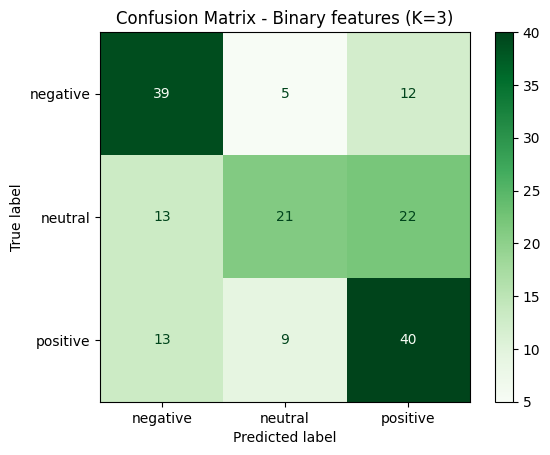

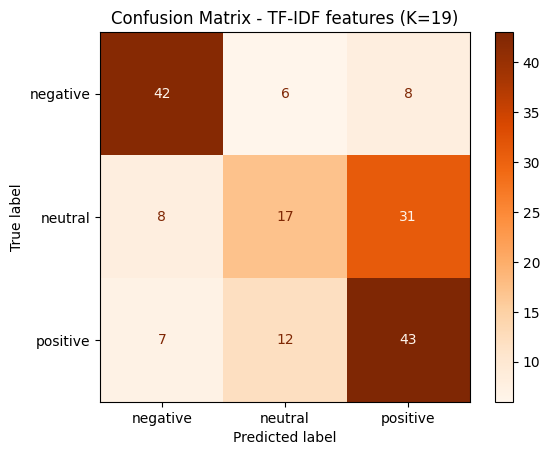

In [175]:
# Evaluate the optimal kNN models with the best K values
knn_bin_optimal = KNeighborsClassifier(n_neighbors=optimal_k_binary, metric='cosine')
knn_bin_optimal.fit(X_train_bin, y_train_bin)

y_pred_knn_bin_optimal = knn_bin_optimal.predict(X_test_bin)
acc_score_knn_bin_optimal = accuracy_score(y_test_bin, y_pred_knn_bin_optimal)
print("Optimal Binary kNN Accuracy: ", acc_score_knn_bin_optimal)

knn_tfidf_optimal = KNeighborsClassifier(n_neighbors=optimal_k_tfidf, metric='cosine')
knn_tfidf_optimal.fit(X_train_tfidf, y_train_tfidf)
y_pred_knn_tfidf_optimal = knn_tfidf_optimal.predict(X_test_tfidf)
acc_score_knn_tfidf_optimal = accuracy_score(y_test_tfidf, y_pred_knn_tfidf_optimal)
print("Optimal TF-IDF kNN Accuracy: ", acc_score_knn_tfidf_optimal)
print(classification_report(y_test_bin, y_pred_knn_bin_optimal, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_knn_bin_optimal, cmap='Greens')

# plot confusion matrices for optimal kNN models
plt.title(f"Confusion Matrix - Binary features (K={optimal_k_binary})")
print(classification_report(y_test_tfidf, y_pred_knn_tfidf_optimal, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_tfidf, y_pred_knn_tfidf_optimal, cmap='Oranges')
plt.title(f"Confusion Matrix - TF-IDF features (K={optimal_k_tfidf})")
plt.show()

**Analyze**: The binary feature kNN has an accuracy of 0.627 while the TF-IDF kNN has an accuracy of 0.593. The binary feature kNN is better at predicting the positive and negative sentiment, while the TF-IDF kNN is better at predicting the neutral sentiment. This is because the binary feature kNN is more sensitive to the presence of certain words that are indicative of positive or negative sentiment, while the TF-IDF kNN is more sensitive to the overall frequency of words in the document.

The gap between the two models is not very large, but it is still significant. The binary feature kNN is better at predicting the sentiment of the documents. Since the each document is relatively short, the presence of certain words is more important than the overall frequency of words in the document. Therefore, the binary feature kNN is better at capturing the sentiment of the documents.

## **Phase 3: Unsupervised Learning**
* Use the same preprocessing and vectorization pipeline as in Phase 2.
* Come up with questions or exploratory questions that can be investigated using unsupervised techniques
and clearly describe them.

Apply:
- k-means clustering
- hierarchical clustering
- DBSCAN (optional)

Implement the methods, run experiments, and analyze the results.
Some questions to explore:
- Do documents naturally cluster by category or sentiment?
- Are mixed-category documents grouped differently from single-category documents?
- Which categories are most similar to each other?

Discuss:
- Whether the resulting clusters match the expected structure of the corpus,
- Which vectorization method produced more meaningful clusters,

Include visualizations where appropriate (for example, dendrograms or 2D projections)

### **K-Means Clustering**


#### **Question 1: Which categories are most similar to each other?**
In this task, we will use K-Means clustering to predict the similar vocabulary between each category. Due to some documents are in 2 categories, we will only use the documents that belong to one category. Additionally, the samples are randomly pick from each category with the same amount of sample. There are 5 catergory, therefore, the value of K is 5 and it will choose the random centriod. Then we cross table to find the score between each category and present them in percentage.


(297, 5)
54
category_1
1    54
2    54
3    54
4    54
5    54
Name: count, dtype: int64

 Similarity Cross table in Percentage
Predicted Category     1     2     3     4     5
True Category                                   
1                   66.7  29.6   3.7   0.0   0.0
2                    1.9  96.3   1.9   0.0   0.0
3                    0.0  46.3  51.9   1.9   0.0
4                    0.0  31.5   1.9  66.7   0.0
5                    0.0  24.1   5.6   3.7  66.7


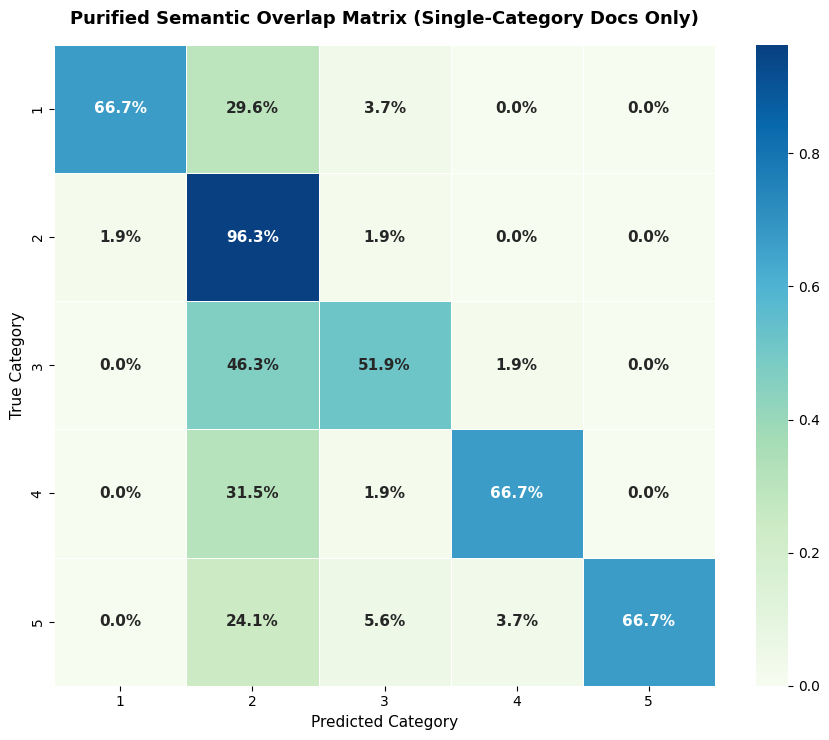

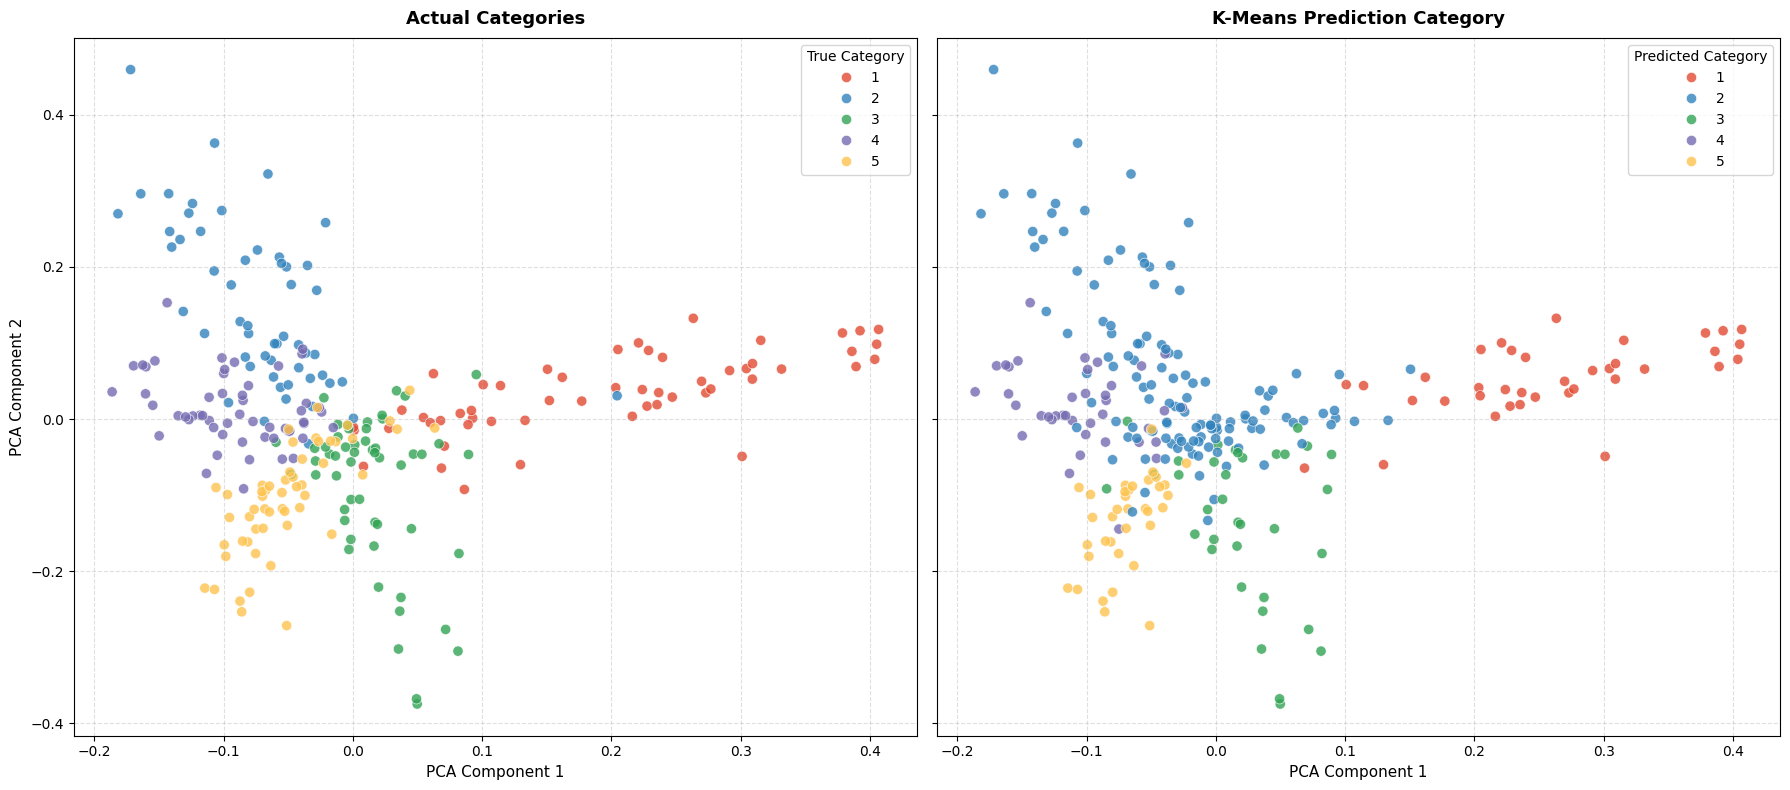

In [176]:
# drop the row with 2 categories
df_mono = df[
    df['category_2'].isna() |
    (df['category_2'].astype(str).str.strip() == 'None') |
    (df['category_2'].astype(str).str.strip() == 'none') |
    (df['category_1'] == df['category_2'])
].copy()
print(df_mono.shape)

# reduce the weight
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.85,
    min_df=2,
    ngram_range=(1, 2)
)

# get the same number of sample in each category.
min_category = df_mono['category_1'].value_counts().min()
print(min_category)

df_bal_cate = df_mono.groupby('category_1').sample(n=min_category ,random_state=RANDOM_STATE).copy()
print(df_bal_cate['category_1'].value_counts())

# K-mean clustering with TF-IDF features on catergory
X_tfidf_cate = tfidf_vectorizer.fit_transform(df_bal_cate['text'])
normalizer = Normalizer(copy=False)
X_tfidf_norm = normalizer.fit_transform(X_tfidf_cate).toarray()

kmeans_category = KMeans(n_clusters=5, init='k-means++', n_init=500,random_state=RANDOM_STATE)
raw_categories = kmeans_category.fit_predict(X_tfidf_norm)
df_bal_cate['cluster_category'] = raw_categories +1
#print(df['cluster_category'].value_counts())

raw_cross_tab_cate = pd.crosstab(df_bal_cate['category_1'], df_bal_cate['cluster_category'])
row_ind, col_ind = linear_sum_assignment(-raw_cross_tab_cate.values)

# Create the decoder map
cluster_to_true_map = {
    raw_cross_tab_cate.columns[col]: raw_cross_tab_cate.index[row]
    for row, col in zip(row_ind, col_ind)
}

# Create new formal columns using the True vs Predicted standard
df_bal_cate['True Category'] = df_bal_cate['category_1']
df_bal_cate['Predicted Category'] = df_bal_cate['cluster_category'].map(cluster_to_true_map)


cross_tab_aligned = pd.crosstab(df_bal_cate['True Category'], df_bal_cate['Predicted Category'])

similarity_matrix = cross_tab_aligned.div(cross_tab_aligned.sum(axis=1), axis=0)

print("\n Similarity Cross table in Percentage")
print((similarity_matrix.round(3) * 100).to_string())


plt.figure(figsize=(9, 7.5))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.1%',
    cmap='GnBu',
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title("Purified Semantic Overlap Matrix (Single-Category Docs Only)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Predicted Category", fontsize=11)
plt.ylabel("True Category", fontsize=11)
plt.tight_layout()
plt.show()


pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_tfidf_norm)

df_bal_cate['pca_x'] = X_pca[:, 0]
df_bal_cate['pca_y'] = X_pca[:, 1]

unique_labels = sorted(df_bal_cate['True Category'].unique())
colors_pool = ["#e34a33", "#3182bd", "#31a354", "#756bb1", "#fec44f"]
unified_palette = dict(zip(unique_labels, colors_pool))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# actual value
sns.scatterplot(
    data=df_bal_cate, x='pca_x', y='pca_y', hue='True Category',
    palette=unified_palette, ax=axes[0], alpha=0.8, s=55, edgecolor='w', linewidth=0.5
)
axes[0].set_title("Actual Categories", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("PCA Component 1", fontsize=11)
axes[0].set_ylabel("PCA Component 2", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# predicted
sns.scatterplot(
    data=df_bal_cate, x='pca_x', y='pca_y', hue='Predicted Category',
    palette=unified_palette, ax=axes[1], alpha=0.8, s=55, edgecolor='w', linewidth=0.5,
    hue_order=unique_labels
)
axes[1].set_title("K-Means Prediction Category", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("PCA Component 1", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



**Analyze:** From the Heatmap, there is a diagonal line accross the figure which shows predicted clusters are mirrored to the actual categories. Addtionally, the scatter plots of the Kmean prediction mapped in similar cluster to their actual category. It is noticeable that category 2 has a highest similary to itself with the value of 96.3% while the other catergories are above 60% similar to itself. Therefore, the Kmean model is reliable in predicted the right group.  

From the graph, the category 2 has the highest similar score to the rest of the category compare to the other. It illustrates the similarity score between category 2 and 3 with the value of 46.3%, and following by catergory 4 with the value of 31.4%. From the scatter plot graph, we can see that category 2, 3, and 4 are quite dense to one and the other. However, the scatter plot is condense to 2 dimension, so it is not completely show the whole image, but it can give a rough view that those three catergory are close to each other.


### **Hierachical Clustering**

**Analyze:**

## **Phase 4: VADER and Sentence-BERT**

In this phase, use pretrained NLP tools, VADER and Sentence-BERT (SBERT), and compare their performance
with the methods from Phases 2 and 3.
* Apply VADER for sentiment analysis on your corpus.
* Use SBERT embeddings for similarity, classification, or clustering tasks.
* Compare the results with the approaches used in Phases 2 and 3.

Discuss:
* Whether pretrained models performed better than the methods from Phases 2 and 3
* Which tasks benefited most from SBERT embeddings,
* Strengths and limitations of pretrained models on small datasets

## **Group Contribution**


* Andrew Maciborski: Part 2 (2nd half)
* Vincent Chau:
* Lyda Taing: Tokenization and Vectorization, KNN prediction sentiment
* Christie Wong: Logistic Regression
* Daniel Remedios: kNN

In [177]:
#submisson
#!sudo apt-get update
#!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
#!pip install pypandoc
#!jupyter nbconvert --log-level DEBUG --to pdf "Final_Project_Phase2.ipynb"